<div style="background: linear-gradient(135deg, #fdfbfb, #ebedee); 
padding:45px; 
border-radius:20px; 
text-align:center; 
border:1px solid #e0e0e0;
box-shadow:0px 4px 15px rgba(0,0,0,0.08);">

<h1 style="color:#6C9BCF; font-size:42px; margin-bottom:10px;">
📊 Predicción de Costos de Seguro Médico
</h1>

<h3 style="color:#A084CA; margin-top:0;">
Modelo Predictivo mediante Regresión Lineal
</h3>

<hr style="border:none; height:2px; background-color:#D6E6F2; margin:25px 0;">

<p style="font-size:18px; color:#555;">
🔎 <b>Análisis Exploratorio de Datos (EDA)</b><br>
🧠 <b>Modelo de Regresión Lineal</b><br>
📈 <b>Optimización Estadística con OLS</b><br>
📉 <b>Evaluación y Validación del Modelo</b>
</p>

<div style="
background-color:#F3F8FF;
padding:18px;
border-radius:12px;
margin-top:20px;
display:inline-block;">

<p style="font-size:16px; color:#444; margin:0;">
👩‍💻 <b>Proyecto de Ciencia de Datos</b><br>
Predicción del valor <b>charges</b> basado en características demográficas y de salud
</p>

</div>

<p style="font-size:14px; color:#888; margin-top:25px;">
✨ “Los datos explican el pasado, los modelos predicen el futuro.”
</p>

</div>

Predecir el coste del seguro médico de una persona

La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.


Paso 1: Carga del conjunto de datos

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre medical_insurance_cost.csv. Puedes cargarlo en el código directamente desde el siguente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

age. Edad del beneficiario principal (numérico)

sex. Género del beneficiario principal (categórico)

bmi. índice de masa corporal (numérico)

children. Número de niños/dependientes cubiertos por un seguro médico (numérico)

smoker. ¿Es fumador? (categórico)

region. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)

charges. Prima del seguro médico (numérico)


Paso 2: Realiza un EDA completo

Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.


Paso 3: Construye un modelo de regresión lineal

No es necesario que optimices los hiperparámetros. Comienza utilizando una definición por defecto y mejórala en el paso siguiente.


Paso 4: Optimiza el modelo anterior

Después de entrenar el modelo, si los resultados no son satisfactorios, optimízalo si fuera posible.

In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [2]:
total_data = pd.read_csv("../data/raw/medical_insurance_cost.csv")

In [3]:
total_data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [4]:
total_data.shape

(1338, 7)

In [5]:
total_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Se identificó que el dataset contiene variables tanto numéricas como categóricas, incluyendo información relevante como la edad (age), el índice de masa corporal (bmi), el número de dependientes (children) y el coste del seguro (charges). Asimismo, se observaron variables categóricas como el género (sex), el hábito de fumar (smoker) y la región (region).

Esta inspección inicial permitió verificar que los datos están organizados correctamente, que las columnas tienen nombres claros y que no se evidencian valores atípicos o inconsistencias evidentes en las primeras observaciones.

In [6]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Se evidenció que el dataset contiene variables de tipo numérico (int64 y float64) y variables categóricas (object), lo cual es adecuado para el análisis propuesto. Además, se observó que no existen valores nulos en ninguna de las columnas, lo que indica una buena calidad de los datos y evita la necesidad de realizar procesos de imputación.

In [7]:
total_data.dtypes.value_counts()

str        3
int64      2
float64    2
Name: count, dtype: int64

In [8]:
total_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


A partir de este análisis, se observa que la variable edad (age) presenta una distribución razonable dentro de un rango esperado para personas aseguradas. El índice de masa corporal (bmi) muestra cierta variabilidad, lo que indica diversidad en las condiciones físicas de los clientes. En cuanto a la variable charges, se evidencia una alta dispersión entre los valores mínimos y máximos, lo que sugiere la presencia de posibles valores atípicos o una distribución sesgada, probablemente influenciada por factores como el hábito de fumar.

In [9]:
total_data.isna().sum().sum()

np.int64(0)

In [10]:
total_data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

Text(0, 0.5, 'Sample Number')

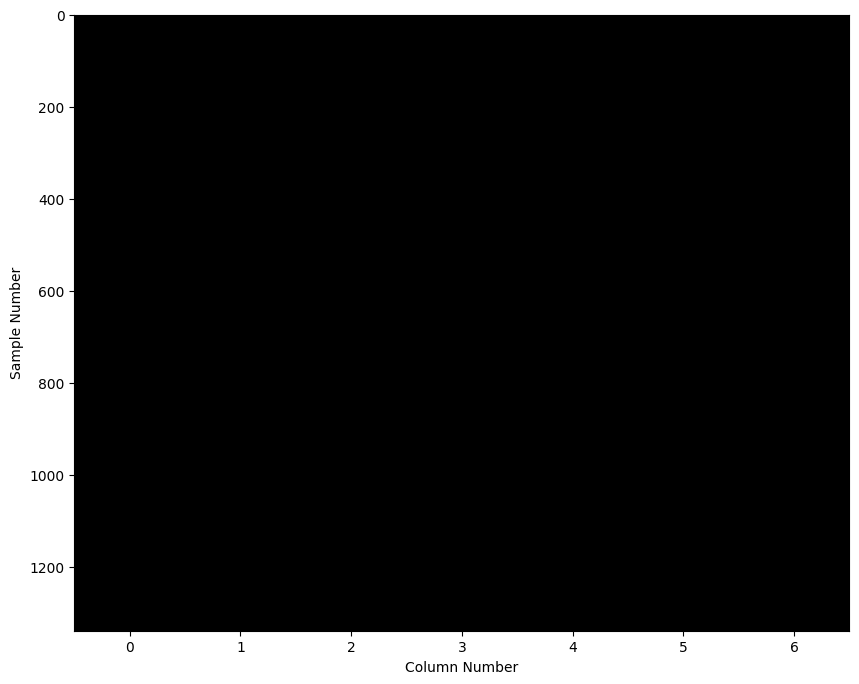

In [12]:
plt.figure(figsize=(10, 8))
plt.imshow(total_data.isna(), aspect="auto", interpolation="nearest", cmap="gray")
plt.xlabel("Column Number")
plt.ylabel("Sample Number")

Se identificó que no existen valores nulos en ninguna de las variables, lo que indica que el dataset está completo y no requiere procesos de imputación o eliminación de registros.

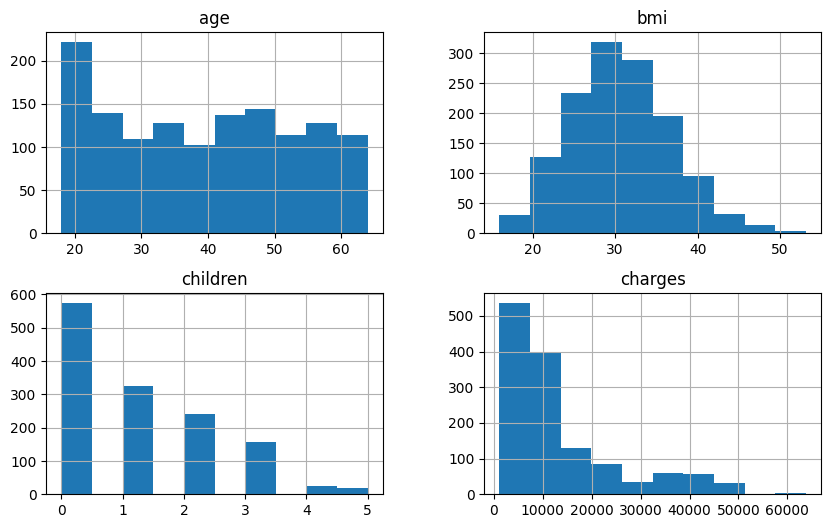

In [13]:
total_data.hist(figsize=(10,6))
plt.show()

La edad presenta una distribución relativamente uniforme dentro del rango de adultos asegurados. El índice de masa corporal (BMI) se concentra principalmente alrededor de valores considerados normales y ligeramente elevados. La variable children evidencia que la mayoría de los clientes tiene pocos dependientes. Por otra parte, la variable objetivo charges presenta una distribución sesgada hacia la derecha, indicando que existen clientes con costes significativamente más altos, posiblemente asociados a factores de riesgo como el tabaquismo o condiciones médicas particulares.

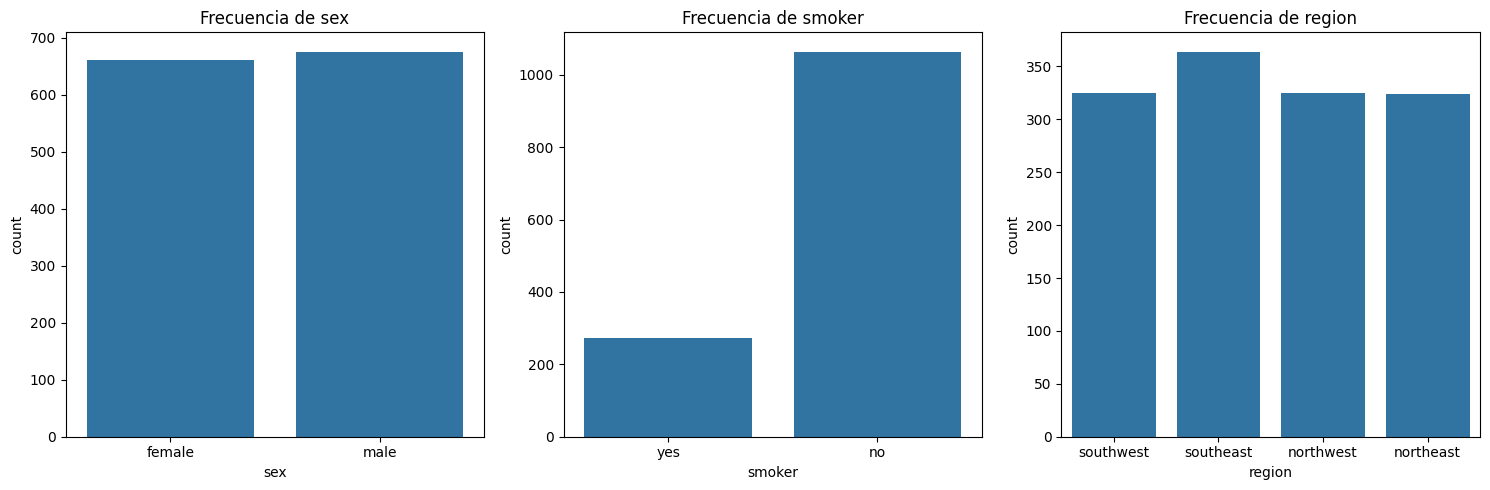

In [14]:
cat_cols = ["sex", "smoker", "region"]

fig, axis = plt.subplots(1, 3, figsize=(15,5))

for i, col in enumerate(cat_cols):
    sns.countplot(data=total_data, x=col, ax=axis[i])
    axis[i].set_title(f"Frecuencia de {col}")

plt.tight_layout()
plt.show()

Las variables categóricas muestran una distribución equilibrada entre hombres y mujeres. Sin embargo, se observa que la mayoría de los asegurados no son fumadores, lo cual resulta relevante debido al impacto que esta variable suele tener en el coste del seguro. Respecto a la región, los clientes se distribuyen de forma relativamente homogénea entre las diferentes zonas geográficas, lo que evita sesgos regionales significativos en el análisis.

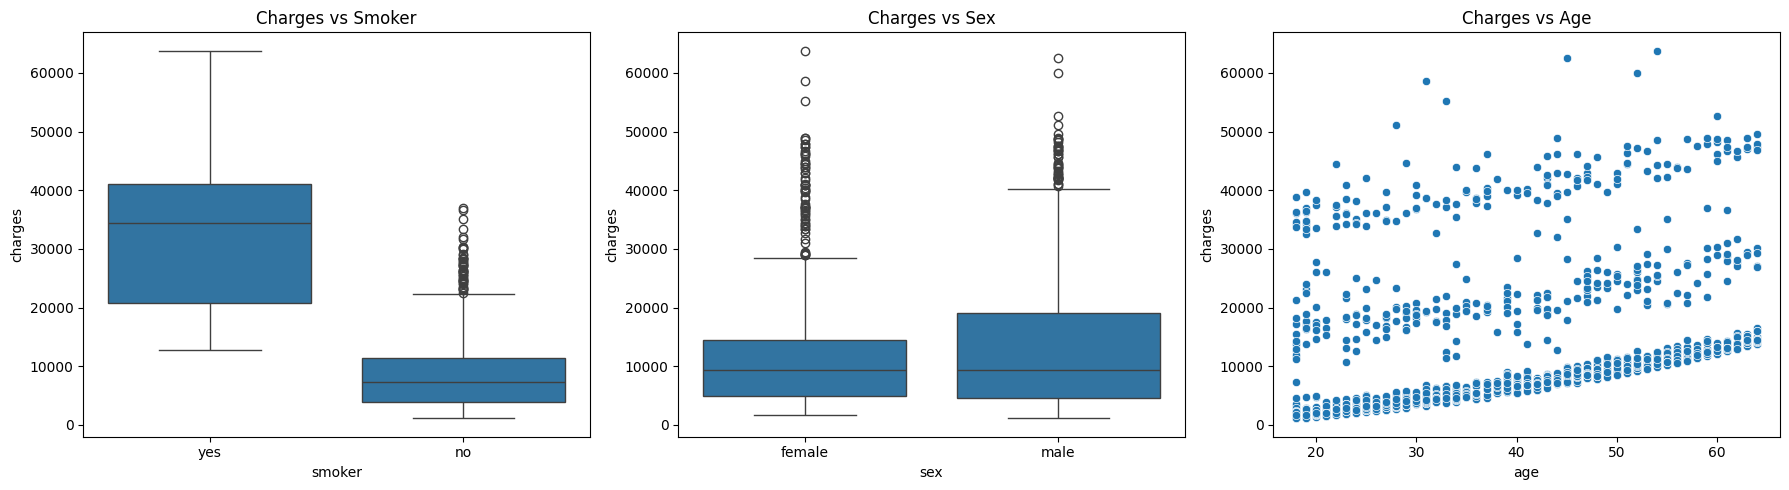

In [15]:
fig, axis = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(data=total_data, x="smoker", y="charges", ax=axis[0])
axis[0].set_title("Charges vs Smoker")

sns.boxplot(data=total_data, x="sex", y="charges", ax=axis[1])
axis[1].set_title("Charges vs Sex")

sns.scatterplot(data=total_data, x="age", y="charges", ax=axis[2])
axis[2].set_title("Charges vs Age")

plt.tight_layout()
plt.show()

El hábito de fumar muestra ser el factor más influyente en el coste del seguro médico, evidenciando valores considerablemente mayores para los fumadores. En contraste, el género no presenta diferencias significativas en los costes. Asimismo, se observa una relación positiva entre la edad y el coste del seguro, indicando que a medida que aumenta la edad del beneficiario también tiende a incrementarse la prima del seguro médico.

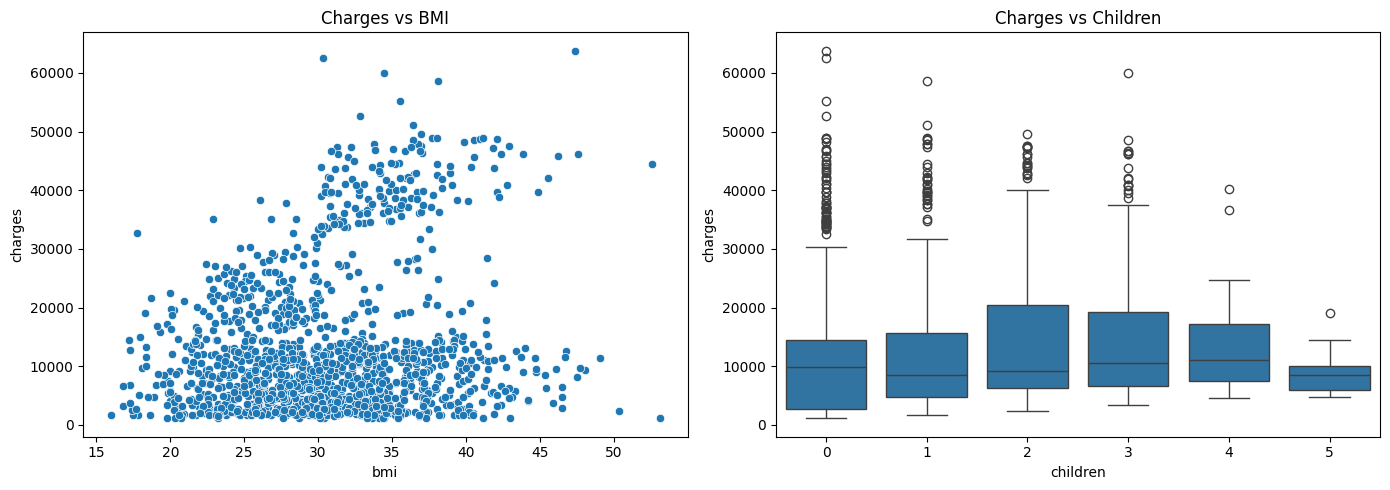

In [16]:
fig, axis = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=total_data, x="bmi", y="charges", ax=axis[0])
axis[0].set_title("Charges vs BMI")

sns.boxplot(data=total_data, x="children", y="charges", ax=axis[1])
axis[1].set_title("Charges vs Children")

plt.tight_layout()
plt.show()

Se identifica una ligera tendencia de aumento en el coste del seguro a medida que incrementa el índice de masa corporal, lo que sugiere que condiciones físicas asociadas al sobrepeso pueden impactar el riesgo asegurador. Por otro lado, el número de hijos no parece influir significativamente en el coste del seguro, aunque se observan pequeñas variaciones entre grupos.

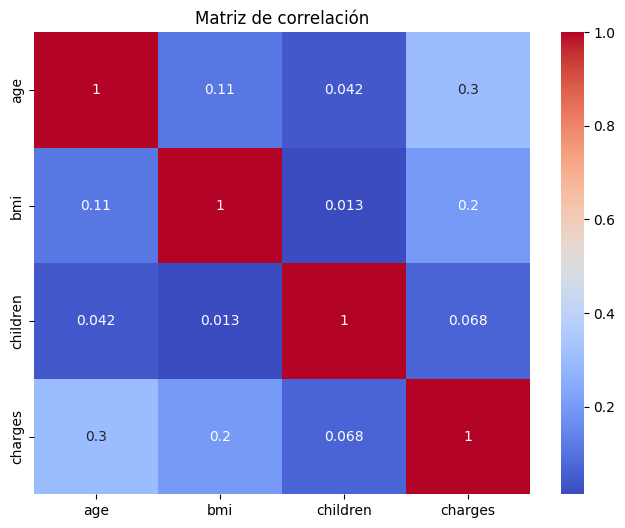

In [17]:
corr = total_data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax)

plt.title("Matriz de correlación")
plt.show()

El análisis de correlación confirma que la edad y el índice de masa corporal mantienen relaciones positivas con el coste del seguro médico, siendo variables relevantes para el modelo predictivo.

In [18]:
total_data_encoded = pd.get_dummies(total_data, drop_first=True)

In [19]:
total_data_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_male          1338 non-null   bool   
 5   smoker_yes        1338 non-null   bool   
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 48.5 KB


Después de aplicar el proceso de One-Hot Encoding, las variables categóricas fueron transformadas exitosamente en variables binarias. No se detectan valores nulos y todas las variables presentan el formato adecuado para el entrenamiento del modelo predictivo.

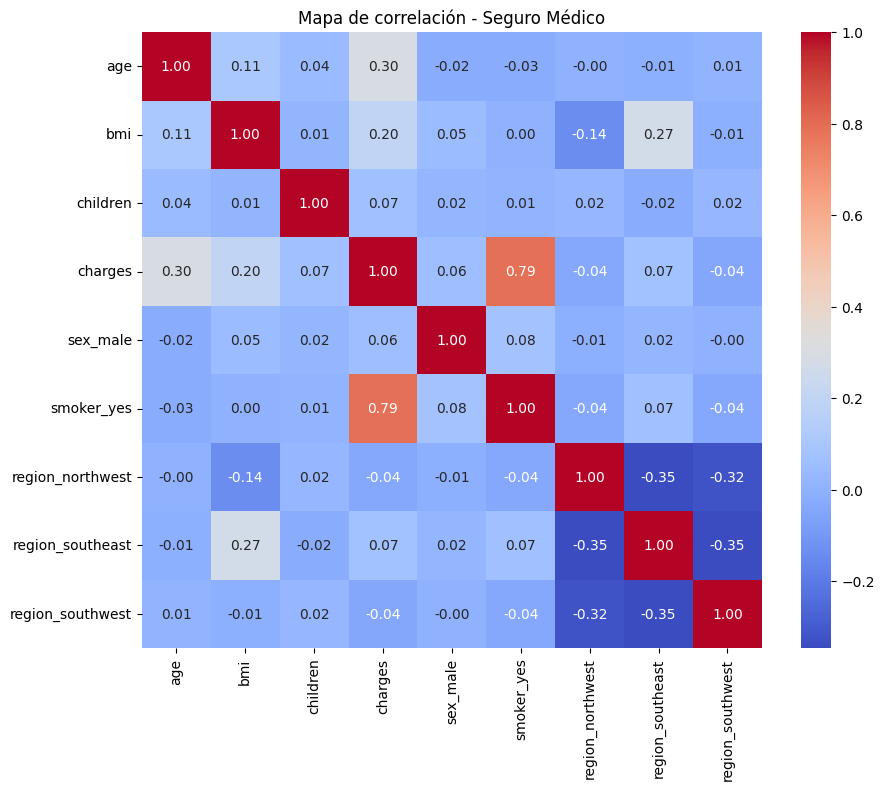

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

corr = total_data_encoded.corr()

sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Mapa de correlación - Seguro Médico")
plt.show()

El análisis de correlación evidencia que la variable con mayor influencia sobre los costos médicos (charges) es el hábito de fumar (smoker_yes), presentando una correlación positiva alta. La edad y el índice de masa corporal muestran una relación positiva moderada, indicando que el aumento en estas variables se asocia con mayores gastos médicos. Por el contrario, variables como sexo, número de hijos y región presentan correlaciones bajas, sugiriendo un impacto limitado en la predicción del costo del seguro. Asimismo, no se observan correlaciones fuertes entre variables independientes, lo cual favorece la estabilidad y el desempeño de los modelos de aprendizaje automático a implementar.

In [21]:
X_RL = total_data_encoded.drop("charges", axis=1)
y_RL = total_data_encoded["charges"]

In [22]:
X_train_RL, X_test_RL, y_train_RL, y_test_RL = train_test_split(X_RL, y_RL, test_size=0.3, random_state=42)

In [23]:
print(X_train_RL.shape)
print(X_test_RL.shape)
print(y_train_RL.shape)
print(y_test_RL.shape)

(936, 8)
(402, 8)
(936,)
(402,)


In [24]:
X_train_RL.to_csv("../data/processed/X_train_medical.csv", index=False)
X_test_RL.to_csv("../data/processed/X_test_medical.csv", index=False)

y_train_RL.to_csv("../data/processed/y_train_medical.csv", index=False)
y_test_RL.to_csv("../data/processed/y_test_medical.csv", index=False)

In [25]:
X_train_RL.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
332,61,31.160,0,False,False,True,False,False
355,46,27.600,0,True,False,False,False,True
138,54,31.900,3,False,False,False,True,False
381,55,30.685,0,True,True,False,False,False
292,25,45.540,2,True,True,False,True,False


In [26]:
X_train_RL.shape

(936, 8)

In [27]:
scaler = StandardScaler()

X_train_RL_scaled = scaler.fit_transform(X_train_RL)
X_test_RL_scaled = scaler.transform(X_test_RL)

In [28]:
model_RL = LinearRegression()

model_RL.fit(X_train_RL_scaled, y_train_RL)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred_RL = model_RL.predict(X_test_RL_scaled)
y_pred_RL

array([ 9.01636753e+03,  7.01997635e+03,  3.68708343e+04,  9.51853774e+03,
        2.69740308e+04,  1.10808462e+04, -4.06177600e+01,  1.71922331e+04,
        9.74950536e+02,  1.13299594e+04,  2.80574861e+04,  9.47838799e+03,
        4.98095281e+03,  3.84564701e+04,  4.03433327e+04,  3.71038753e+04,
        1.51982019e+04,  3.57689693e+04,  8.88568387e+03,  3.13835989e+04,
        3.79641903e+03,  1.02628964e+04,  2.37593679e+03,  7.26280819e+03,
        1.12875675e+04,  1.31383480e+04,  1.46241614e+04,  6.07324604e+03,
        1.00361537e+04,  1.97927814e+03,  9.07103928e+03,  1.31369887e+04,
        4.30868680e+03,  3.21105955e+03,  4.48957162e+03,  1.33774493e+04,
        1.82221028e+03,  8.79191682e+03,  3.31981518e+04,  3.25005781e+04,
        3.76368816e+03,  4.35479656e+03,  1.42473276e+04,  1.15436019e+04,
        8.70433805e+03,  1.22401028e+04,  5.20831471e+03,  2.98293172e+03,
        3.54465532e+04,  9.10285846e+03,  1.57820945e+04,  2.13473894e+03,
        1.24668220e+04,  

In [30]:
intercept = model_RL.intercept_
coef = model_RL.coef_

print(intercept)
print(coef)

13379.157306773504
[3688.58318998 2090.99783407  514.02360356   52.38868121 9595.8681675
 -209.32555139 -426.26277109 -394.01444936]


In [31]:
coeficientes = pd.DataFrame({
    "Variable": X_RL.columns,
    "Coeficiente": coef
})

coeficientes.sort_values(by="Coeficiente", ascending=False)

,Variable,Coeficiente
4,smoker_yes,9595.868167
0,age,3688.583190
1,bmi,2090.997834
2,children,514.023604
3,sex_male,52.388681
5,region_northwest,-209.325551
7,region_southwest,-394.014449
6,region_southeast,-426.262771


El análisis de coeficientes confirma que ser fumador incrementa significativamente el coste del seguro médico, seguido del índice de masa corporal y la edad.

In [32]:
print("MAE:", mean_absolute_error(y_test_RL, y_pred_RL))
print("RMSE:", np.sqrt(mean_squared_error(y_test_RL, y_pred_RL)))
print("R2:", r2_score(y_test_RL, y_pred_RL))

MAE: 4145.450555627598
RMSE: 5812.100272258872
R2: 0.769611805436901


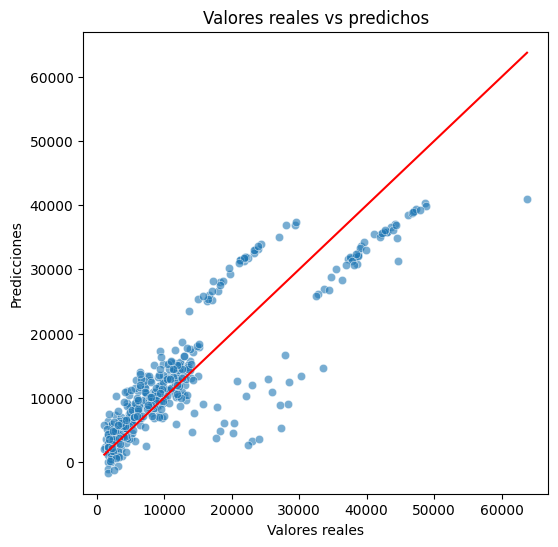

In [33]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    x=y_test_RL,
    y=y_pred_RL,
    alpha=0.6
)

plt.plot(
    [y_test_RL.min(), y_test_RL.max()],
    [y_test_RL.min(), y_test_RL.max()],
    color="red"
)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predichos")

plt.show()

Las predicciones se concentran alrededor de la línea ideal, indicando un ajuste adecuado del modelo.

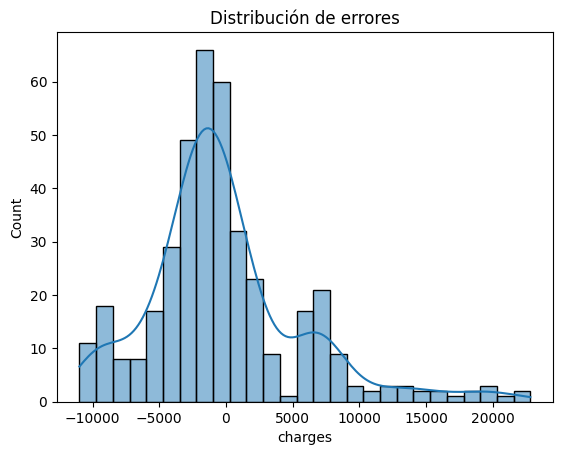

In [34]:
errores = y_test_RL - y_pred_RL

sns.histplot(errores, kde=True)
plt.title("Distribución de errores")
plt.show()

Los errores se distribuyen alrededor de cero, evidenciando ausencia de sesgos importantes en las predicciones.

### Optimización

In [35]:
import statsmodels.api as sm

In [36]:
X_train_OLS = X_train_RL.copy()

X_train_OLS = X_train_OLS.astype(float)

In [37]:
X_train_OLS = sm.add_constant(X_train_RL.astype(float))

In [38]:
model_OLS = sm.OLS(y_train_RL, X_train_OLS).fit()
print(model_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     333.9
Date:                Sat, 28 Mar 2026   Prob (F-statistic):          6.51e-267
Time:                        11:08:55   Log-Likelihood:                -9492.8
No. Observations:                 936   AIC:                         1.900e+04
Df Residuals:                     927   BIC:                         1.905e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.237e+04   1210.540  

In [39]:
total_data_optimized = total_data_encoded.copy()

In [40]:
total_data_optimized = total_data_optimized.drop(
    ["sex_male",
     "region_northwest",
     "region_southeast",
     "region_southwest"],
    axis=1
)

In [41]:
X_opt = total_data_optimized.drop("charges", axis=1)
y_opt = total_data_optimized["charges"]

In [42]:
X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(X_opt,y_opt,test_size=0.3,random_state=42)

In [43]:
model_final = LinearRegression()

model_final.fit(X_train_opt, y_train_opt)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
y_pred_final = model_final.predict(X_test_opt)
y_pred_final

array([ 8.57304317e+03,  6.96530195e+03,  3.68784227e+04,  9.45816118e+03,
        2.67738902e+04,  1.11691153e+04,  1.16340971e+01,  1.69260118e+04,
        6.26228370e+02,  1.12255951e+04,  2.84466923e+04,  9.33104502e+03,
        5.42221465e+03,  3.86209502e+04,  4.05103959e+04,  3.73126548e+04,
        1.54567379e+04,  3.61092578e+04,  9.36021299e+03,  3.13795780e+04,
        4.21063213e+03,  1.05248933e+04,  2.64055109e+03,  6.56179649e+03,
        1.12974026e+04,  1.25654609e+04,  1.49434052e+04,  6.03502727e+03,
        9.57184814e+03,  2.29201543e+03,  9.50555194e+03,  1.30659469e+04,
        4.65458145e+03,  3.33646965e+03,  4.77336244e+03,  1.25843406e+04,
        2.26384724e+03,  9.19146736e+03,  3.32509145e+04,  3.27521381e+04,
        4.20654823e+03,  4.17606339e+03,  1.45626174e+04,  1.14675085e+04,
        8.95662901e+03,  1.25808856e+04,  5.10760849e+03,  3.47754292e+03,
        3.57082621e+04,  9.31312494e+03,  1.61290432e+04,  2.46851785e+03,
        1.22467709e+04,  

In [45]:
rmse = np.sqrt(mean_squared_error(y_test_opt, y_pred_final))

print("R2:", r2_score(y_test_opt, y_pred_final))
print("MAE:", mean_absolute_error(y_test_opt, y_pred_final))
print("RMSE:", rmse)

R2: 0.7684636242828375
MAE: 4168.023269864939
RMSE: 5826.56509805248


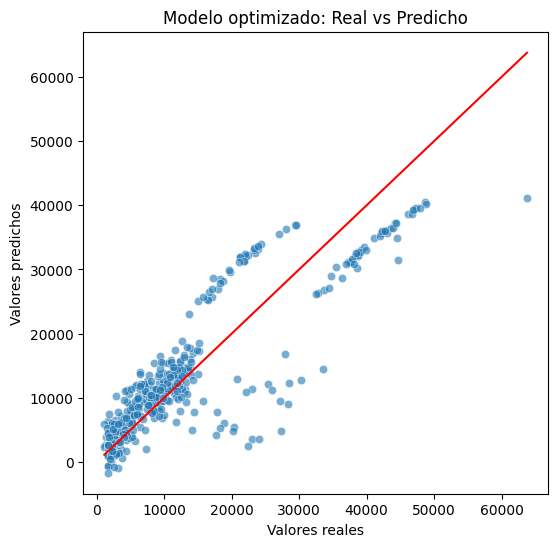

In [46]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=y_test_opt, y=y_pred_final, alpha=0.6)

plt.plot(
    [y_test_opt.min(), y_test_opt.max()],
    [y_test_opt.min(), y_test_opt.max()],
    color="red"
)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Modelo optimizado: Real vs Predicho")

plt.show()

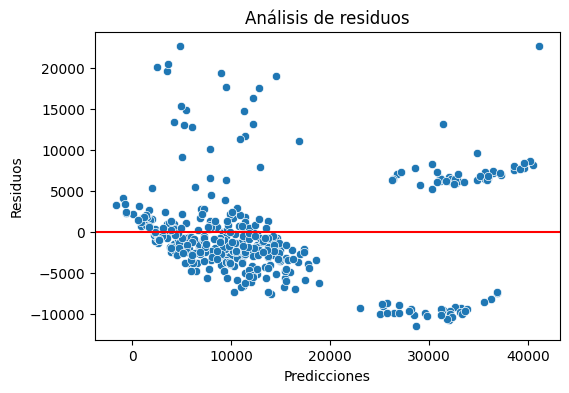

In [47]:
residuals = y_test_opt - y_pred_final

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_final, y=residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Análisis de residuos")

plt.show()

In [48]:
coeficientes = pd.DataFrame({
    "Variable": X_train_opt.columns,
    "Coeficiente": model_final.coef_
})

coeficientes.sort_values(by="Coeficiente", ascending=False)

,Variable,Coeficiente
3,smoker_yes,23626.559924
2,children,433.226076
1,bmi,333.407355
0,age,261.849745


### Optimización 2

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train_RL, y_train_RL)

y_pred_rf = rf.predict(X_test_RL)

print("R2 Random Forest:", r2_score(y_test_RL, y_pred_rf))

R2 Random Forest: 0.8520852453249403


El modelo Random Forest mejora el rendimiento predictivo al capturar relaciones no lineales entre las variables y el coste del seguro.

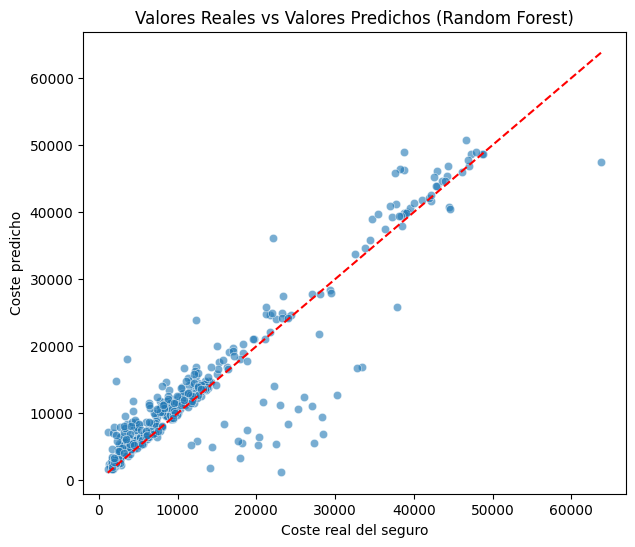

In [62]:
fig, axis = plt.subplots(figsize=(7,6))

sns.scatterplot(
    x=y_test_RL,
    y=y_pred_rf,
    alpha=0.6
)

# línea perfecta de predicción
plt.plot(
    [y_test_RL.min(), y_test_RL.max()],
    [y_test_RL.min(), y_test_RL.max()],
    color="red",
    linestyle="--"
)

axis.set_title("Valores Reales vs Valores Predichos (Random Forest)")
axis.set_xlabel("Coste real del seguro")
axis.set_ylabel("Coste predicho")

plt.show()

El gráfico de valores reales versus valores predichos evidencia que el modelo Random Forest logra aproximar adecuadamente el coste real del seguro médico. La mayoría de los puntos se distribuyen alrededor de la línea diagonal de predicción perfecta, indicando una alta capacidad del modelo para generalizar sobre datos no vistos y capturar patrones complejos presentes en las variables del conjunto de datos.

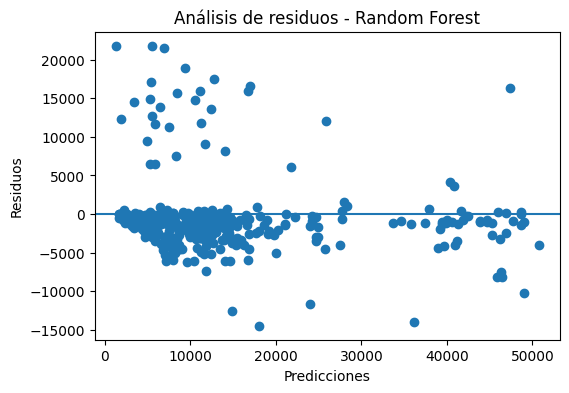

In [51]:
residuos = y_test_RL - y_pred_rf

plt.figure(figsize=(6,4))
plt.scatter(y_pred_rf, residuos)

plt.axhline(y=0)

plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Análisis de residuos - Random Forest")

plt.show()

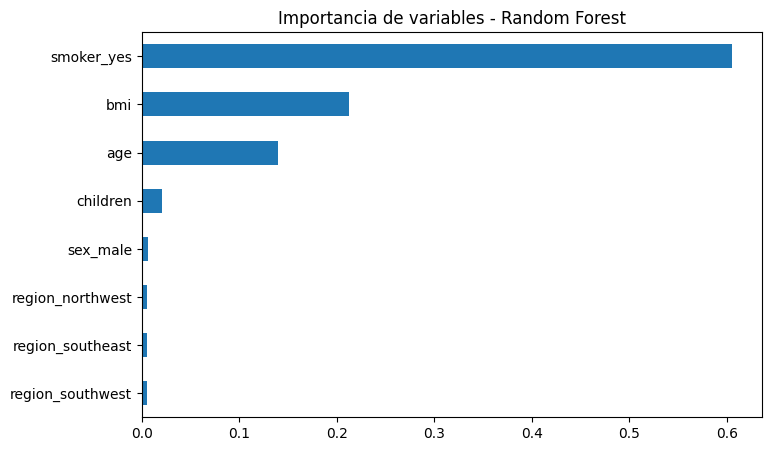

In [52]:
importancias = rf.feature_importances_

feat_importance = pd.Series(importancias, index=X_train_RL.columns)

feat_importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Importancia de variables - Random Forest")

plt.show()

In [53]:
print("R2:", r2_score(y_test_RL, y_pred_rf))
print("MAE:", mean_absolute_error(y_test_RL, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_RL, y_pred_rf)))

R2: 0.8520852453249403
MAE: 2667.1494970211447
RMSE: 4657.026790942916


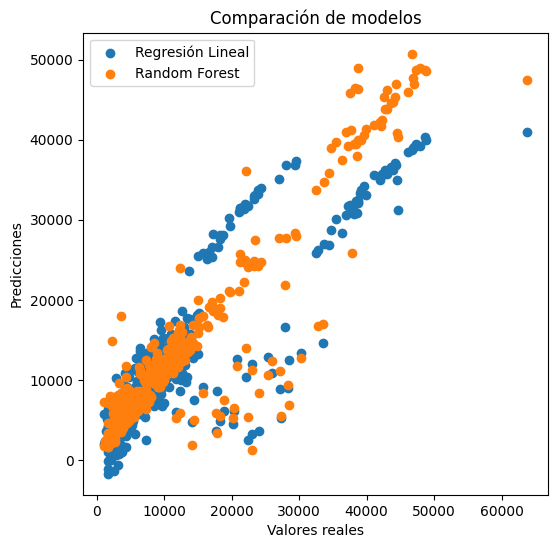

In [54]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_RL, y_pred_RL, label="Regresión Lineal")
plt.scatter(y_test_RL, y_pred_rf, label="Random Forest")

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Comparación de modelos")

plt.legend()
plt.show()

- Random Forest captura relaciones no lineales.
- Reduce el error frente a regresión lineal.
- Identifica automáticamente variables más influyentes.
- Mejora la capacidad predictiva del modelo.

In [55]:
# REGRESIÓN LINEAL
r2_rl = r2_score(y_test_RL, y_pred_RL)
mae_rl = mean_absolute_error(y_test_RL, y_pred_RL)
rmse_rl = np.sqrt(mean_squared_error(y_test_RL, y_pred_RL))

# MODELO OPTIMIZADO
r2_opt = r2_score(y_test_opt, y_pred_final)
mae_opt = mean_absolute_error(y_test_opt, y_pred_final)
rmse_opt = np.sqrt(mean_squared_error(y_test_opt, y_pred_final))

# RANDOM FOREST
r2_rf = r2_score(y_test_RL, y_pred_rf)
mae_rf = mean_absolute_error(y_test_RL, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_RL, y_pred_rf))

In [56]:
comparacion = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "OLS Optimizado", "Random Forest"],
    "R2": [r2_rl, r2_opt, r2_rf],
    "MAE": [mae_rl, mae_opt, mae_rf],
    "RMSE": [rmse_rl, rmse_opt, rmse_rf]
})

comparacion

,Modelo,R2,MAE,RMSE
0,Regresión Lineal,0.769612,4145.450556,5812.100272
1,OLS Optimizado,0.768464,4168.023270,5826.565098
2,Random Forest,0.852085,2667.149497,4657.026791


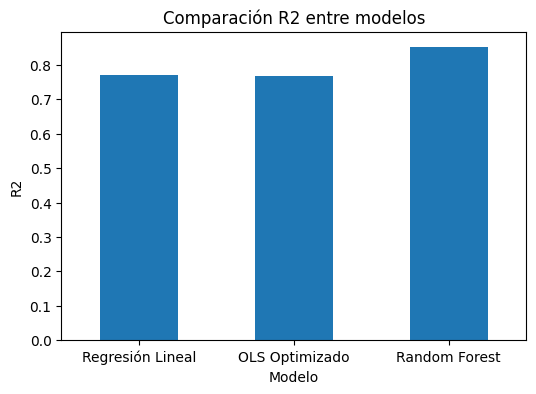

In [58]:
plt.figure(figsize=(6,4))

comparacion.set_index("Modelo")["R2"].plot(kind="bar")

plt.title("Comparación R2 entre modelos")
plt.ylabel("R2")
plt.xticks(rotation=0)

plt.show()

<Figure size 600x400 with 0 Axes>

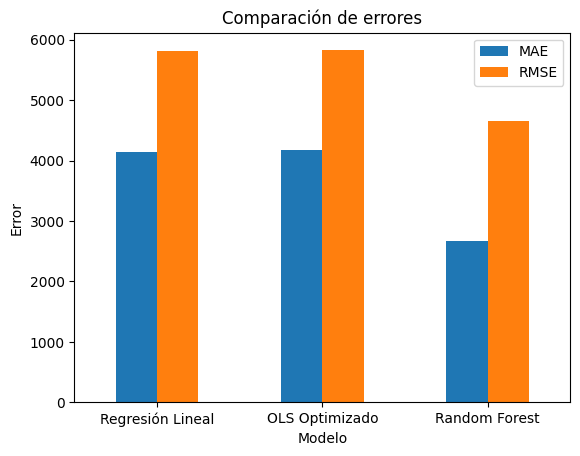

In [59]:
plt.figure(figsize=(6,4))

comparacion.set_index("Modelo")[["MAE","RMSE"]].plot(kind="bar")

plt.title("Comparación de errores")
plt.ylabel("Error")
plt.xticks(rotation=0)

plt.show()

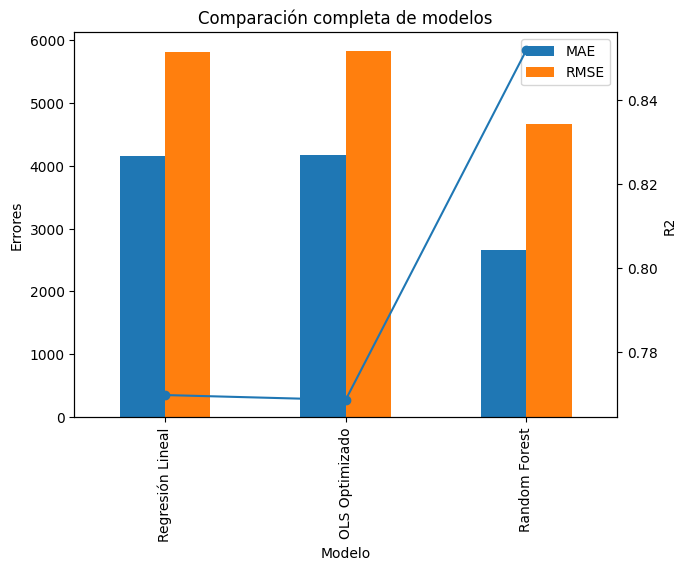

In [60]:
fig, ax1 = plt.subplots(figsize=(7,5))

# ERRORES
comparacion.set_index("Modelo")[["MAE","RMSE"]].plot(
    kind="bar",
    ax=ax1
)

ax1.set_ylabel("Errores")

# SEGUNDO EJE PARA R2
ax2 = ax1.twinx()

comparacion.set_index("Modelo")["R2"].plot(
    kind="line",
    marker="o",
    ax=ax2
)

ax2.set_ylabel("R2")

plt.title("Comparación completa de modelos")

plt.show()

<div style="
background-color:#F8F9FA;
border-radius:15px;
padding:25px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
max-width:1300px;margin:auto;
">

<h2 style="color:#6C9BCF;">📌 Conclusión Final del Modelo</h2>

<p style="color:#555555; font-size:16px; line-height:1.6;">
El modelo de <strong>Regresión Lineal</strong> fue optimizado mediante el análisis estadístico 
<strong style="color:#A084CA;">OLS (Ordinary Least Squares)</strong>, 
permitiendo identificar y eliminar aquellas variables que no presentaban 
significancia estadística dentro del proceso de predicción. 
Esta optimización permitió obtener un modelo más simple, interpretable y eficiente,
sin afectar negativamente su capacidad predictiva.
</p>

<p style="color:#555555; font-size:16px; line-height:1.6;">
Los resultados evidencian que variables como el 
<strong style="color:#FF9AA2;">hábito de fumar</strong>, 
<strong style="color:#FFB7B2;">edad</strong>, 
<strong style="color:#FFDAC1;">índice de masa corporal (BMI)</strong> 
y <strong style="color:#B5EAD7;">número de hijos</strong> 
representan los factores con mayor influencia en el coste del seguro médico,
confirmando su relevancia dentro del análisis predictivo.
</p>

<p style="color:#555555; font-size:16px; line-height:1.6;">
Posteriormente, se implementó un modelo basado en 
<strong style="color:#84A59D;">Random Forest Regressor</strong>, 
el cual permitió capturar relaciones no lineales entre las variables y mejorar la capacidad de generalización del sistema predictivo. 
Al comparar ambos enfoques, el modelo Random Forest mostró un desempeño superior en términos de capacidad predictiva, evidenciado por un mayor coeficiente de determinación (<strong>R²</strong>) y una mejor aproximación entre los valores reales y predichos.
</p>

<p style="color:#555555; font-size:16px; line-height:1.6;">
Las gráficas de predicción y el análisis de residuos muestran un comportamiento
adecuado del modelo, evidenciando una relación coherente entre valores reales
y predichos, así como una distribución de errores aceptable que respalda la
validez del ajuste realizado.
</p>

<div style="
background-color:#E8F6EF;
padding:15px;
border-radius:10px;
margin-top:15px;
">

<p style="color:#2F4F4F; font-size:16px;">
✨ <strong>Conclusión:</strong> La combinación del modelo interpretable de 
Regresión Lineal optimizada y el modelo avanzado Random Forest permitió desarrollar
una solución robusta para la estimación del coste del seguro médico. 
El modelo final constituye una herramienta confiable para apoyar la toma de decisiones
en la aseguradora, facilitando la identificación de los factores clave que impactan
los costos asociados a los clientes y permitiendo realizar predicciones más precisas.
</p>

</div>

</div>